In [3]:
import numpy as np
import matplotlib.pyplot as plt
import h5py
from scipy.constants import physical_constants
%matplotlib inline

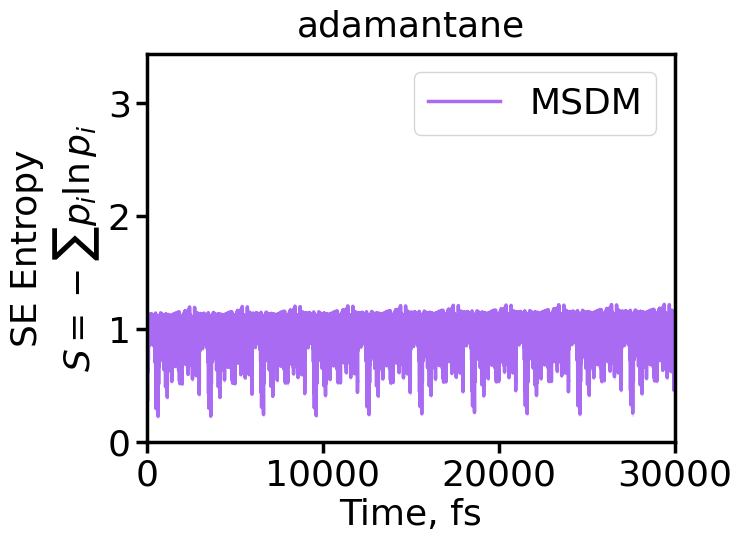

Saved to SE_entropy_adamantane_MSDM_raw.png


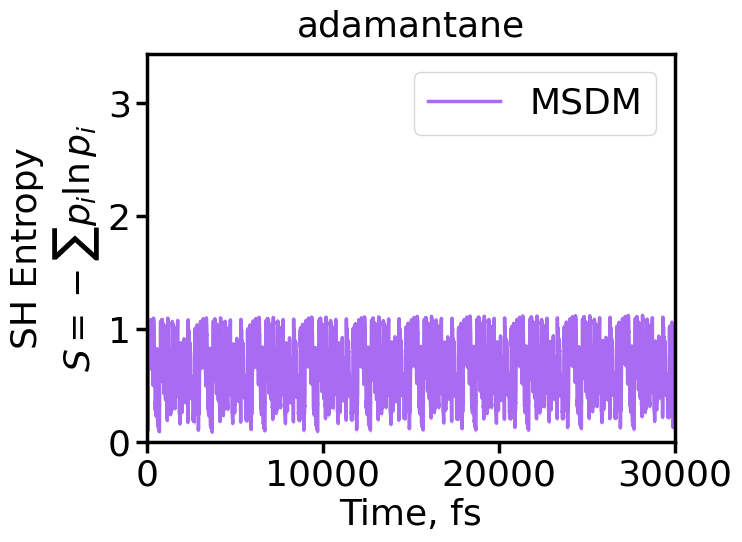

Saved to SH_entropy_adamantane_MSDM_raw.png


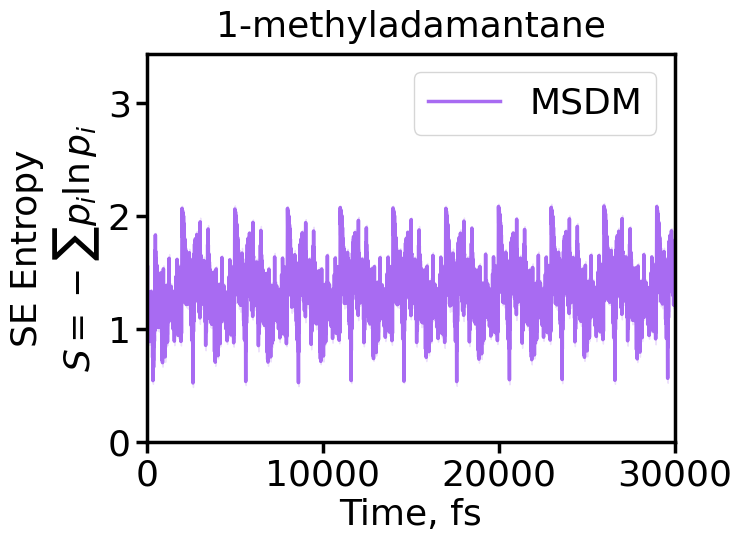

Saved to SE_entropy_1_methyladamantane_MSDM_raw.png


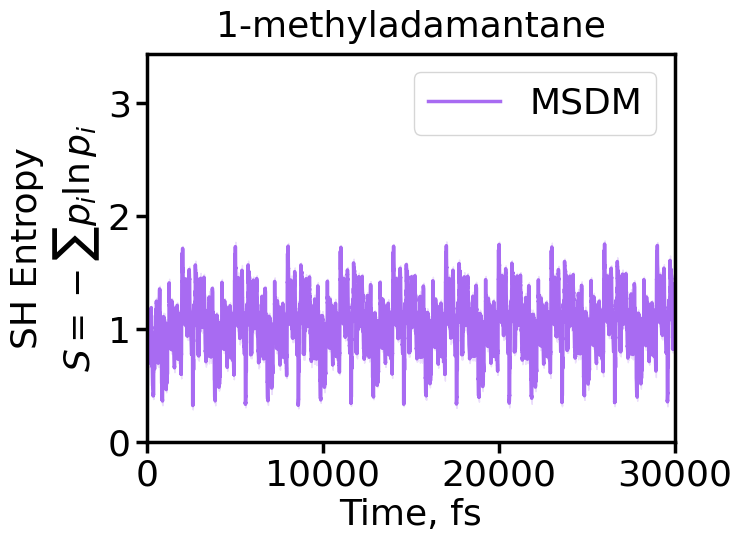

Saved to SH_entropy_1_methyladamantane_MSDM_raw.png


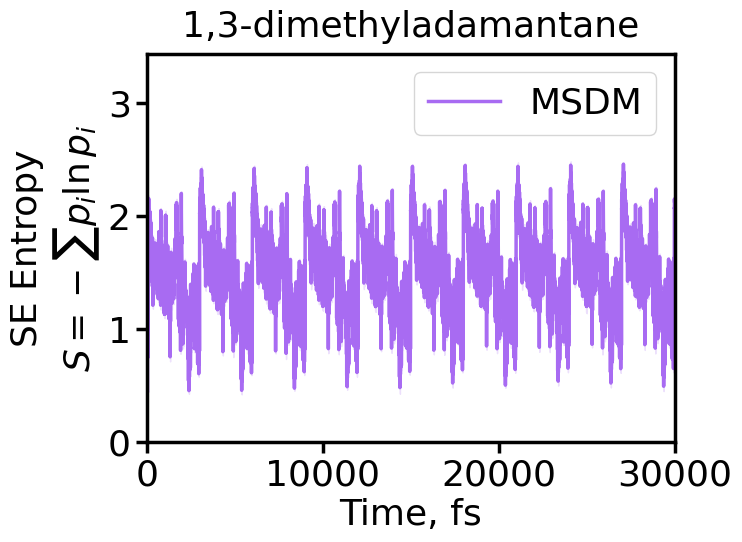

Saved to SE_entropy_13_dimethyladamantane_MSDM_raw.png


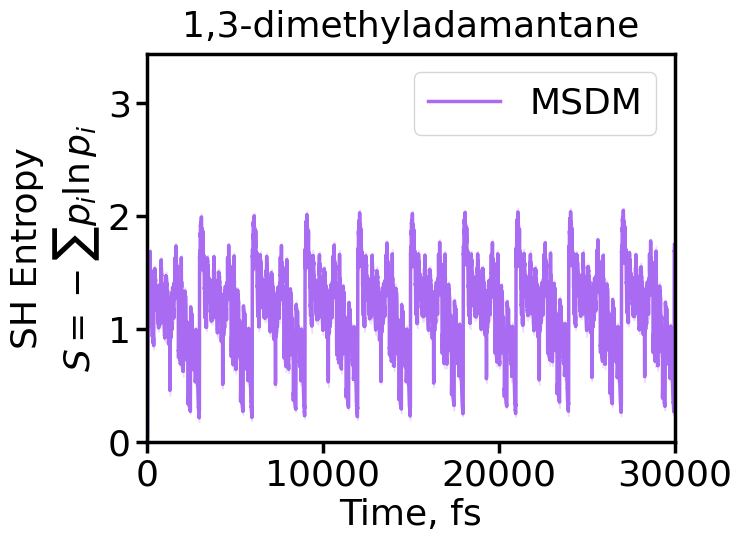

Saved to SH_entropy_13_dimethyladamantane_MSDM_raw.png


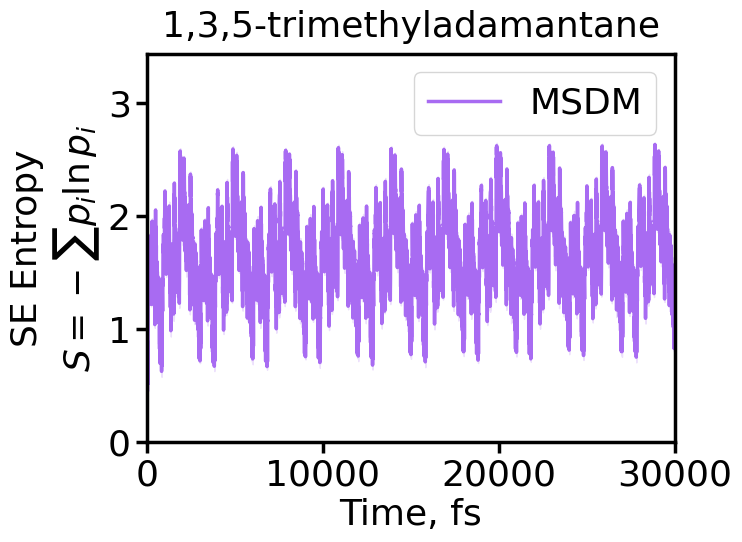

Saved to SE_entropy_135_trimethyladamantane_MSDM_raw.png


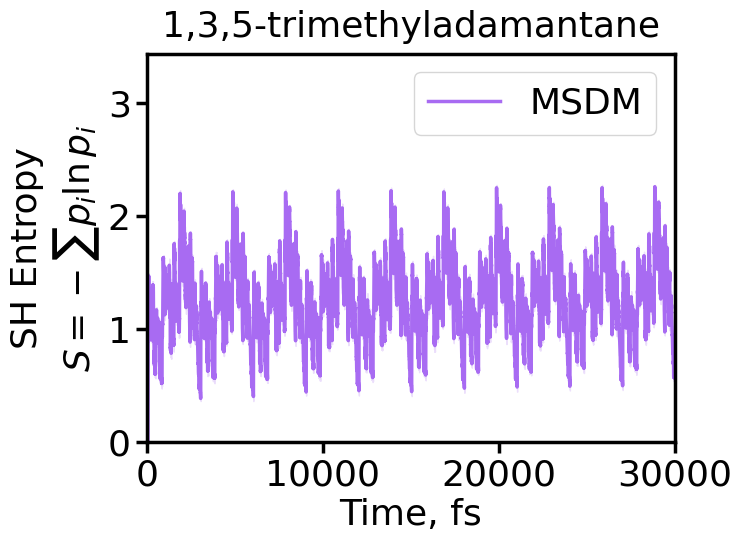

Saved to SH_entropy_135_trimethyladamantane_MSDM_raw.png


In [22]:
# ── Unit conversion ────────────────────────────────────────────────────────
au2fs = physical_constants['atomic unit of time'][0] * 1e15


# ── Shannon entropy (multi-state, NOT normalized) ──────────────────────────
def shannon_entropy_from_pop(pop):
    """
    pop: 2D array (time, n_states)

    Returns raw Shannon entropy:
        S = -sum_i p_i ln(p_i)

    Shape:
        (time,)
    """
    p = np.array(pop, dtype=float)

    # avoid log(0); because p * log(p) = 0 when p = 0
    p_safe = np.where(p > 0.0, p, 1.0)

    S = -np.sum(p * np.log(p_safe), axis=1)

    return S


# ── Systems ────────────────────────────────────────────────────────────────
systems = [
    {
        'title': 'adamantane',
        'path': '../../../0_new_yield/S1_MSDM/{method}_icond_{icond}/mem_data.hdf'
    },
    {
        'title': '1-methyladamantane',
        'path': '../../../1_new_yield/S1_MSDM/{method}_icond_{icond}/mem_data.hdf'
    },
    {
        'title': '1,3-dimethyladamantane',
        'path': '../../../2_new_yield/S1_MSDM/{method}_icond_{icond}/mem_data.hdf'
    },
    {
        'title': '1,3,5-trimethyladamantane',
        'path': '../../../3_new_yield/S1_MSDM/{method}_icond_{icond}/mem_data.hdf'
    },
]


# ── Plot settings ──────────────────────────────────────────────────────────
TITLE_SIZE  = 26
LABEL_SIZE  = 26
TICK_SIZE   = 26
LEGEND_SIZE = 26

plt.rcParams.update({
    "font.size": LABEL_SIZE,
    "lines.linewidth": 2.5
})

methods = ['MSDM']
iconds  = list(range(1, 1000, 100))   # 1, 101, ..., 901; 10 trajectories
colors  = ['#A86BF2']

N = 31
S_MAX = np.log(N)   # upper bound for raw entropy, ~3.43


# ── Read and calculate entropy data ────────────────────────────────────────
entropy_data = {}

for system in systems:
    title = system['title']
    entropy_data[title] = {}

    for method in methods:
        all_se = []
        all_sh = []
        md_time = None

        for icond in iconds:
            path = system['path'].format(method=method, icond=icond)

            try:
                with h5py.File(path, 'r') as F:
                    se_pop = np.array(F['se_pop_adi/data'])
                    sh_pop = np.array(F['sh_pop_adi/data'])
                    md_time = np.array(F['time/data']) * au2fs

            except FileNotFoundError:
                print(f"Not found: {path}, skipping.")
                continue

            except KeyError as e:
                print(f"Key error {e}: {path}, skipping.")
                continue

            all_se.append(shannon_entropy_from_pop(se_pop))
            all_sh.append(shannon_entropy_from_pop(sh_pop))

        if len(all_se) == 0:
            print(f"No data for {title} {method}, skipping.")
            continue

        all_se = np.array(all_se)
        all_sh = np.array(all_sh)

        entropy_data[title][method] = {
            'time': md_time,
            'mean_se': np.mean(all_se, axis=0),
            'std_se':  np.std(all_se, axis=0),
            'mean_sh': np.mean(all_sh, axis=0),
            'std_sh':  np.std(all_sh, axis=0),
        }


# ── Safe filename helper ───────────────────────────────────────────────────
def make_safe_filename(title):
    """
    Convert system title into a filename-safe string.
    """
    safe_title = (
        title
        .replace(',', '')
        .replace(' ', '_')
        .replace('-', '_')
    )

    return safe_title


# ── Single entropy plot function ───────────────────────────────────────────
def plot_single_entropy(
    time,
    mean,
    std,
    title,
    ylabel,
    figurename,
    legend_loc='upper right'
):
    fig, ax = plt.subplots(figsize=(8, 6))

    color = colors[0]

    ax.plot(
        time,
        mean,
        color=color,
        linewidth=2.5,
        label='MSDM'
    )

    ax.fill_between(
        time,
        mean - std,
        mean + std,
        color=color,
        alpha=0.2
    )

    ax.set_title(title, fontsize=TITLE_SIZE, pad=12)

    ax.set_xlim(0, 30000)
    ax.set_xticks(np.arange(0, 30001, 10000))

    ax.set_ylim(0.0, S_MAX)

    ax.set_xlabel('Time, fs', fontsize=LABEL_SIZE)
    ax.set_ylabel(ylabel, fontsize=LABEL_SIZE)

    ax.tick_params(
        axis='both',
        labelsize=TICK_SIZE,
        width=2.5,
        length=8
    )

    ax.set_facecolor('white')

    for spine in ax.spines.values():
        spine.set_linewidth(2.5)

    ax.legend(fontsize=LEGEND_SIZE, loc=legend_loc)

    fig.patch.set_facecolor('white')
    plt.tight_layout()

    plt.savefig(figurename, dpi=600, bbox_inches='tight')
    plt.show()

    print(f"Saved to {figurename}")


# ── Generate 8 separate subfigures ─────────────────────────────────────────
for system in systems:
    title = system['title']

    if 'MSDM' not in entropy_data[title]:
        print(f"No MSDM data for {title}, skipping.")
        continue

    data = entropy_data[title]['MSDM']

    safe_title = make_safe_filename(title)

    # SE entropy figure
    plot_single_entropy(
        time=data['time'],
        mean=data['mean_se'],
        std=data['std_se'],
        title=title,
        ylabel='SE Entropy\n$S = -\\sum p_i \\ln p_i$',
        figurename=f'SE_entropy_{safe_title}_MSDM_raw.png',
        legend_loc='upper right'
    )

    # SH entropy figure
    plot_single_entropy(
        time=data['time'],
        mean=data['mean_sh'],
        std=data['std_sh'],
        title=title,
        ylabel='SH Entropy\n$S = -\\sum p_i \\ln p_i$',
        figurename=f'SH_entropy_{safe_title}_MSDM_raw.png',
        legend_loc='upper right'
    )